# NWB File Visualization Notebook

## Required Libraries

In [1]:
from nwbwidgets import nwb2widget
from nwbwidgets.view import default_neurodata_vis_spec
from hdmf_zarr import NWBZarrIO
import pynwb
from pathlib import Path

## Loading the NWB File
You can use the `NWBZarrIO` class from `hdmf_zarr` to read a `.nwb` file. The `read()` method returns the NWB file object.

In [2]:
# Define the file path
filepath = Path(r'/data/multiplane-ophys_770966_2025-05-06_15-46-31_processed_2025-05-07_17-49-52/multiplane-ophys_770966_2025-05-06_15-46-31_processed_2025-05-07_18-14-19.nwb')
print("Exists:", filepath.exists())
print("Is dir:", filepath.is_dir())
print("Is file:", filepath.is_file())
# Open and read the NWB file
io = NWBZarrIO(filepath, mode="r")
nwb = io.read()

# Show summary of the NWB file
print(nwb)

Exists: True
Is dir: True
Is file: False
root pynwb.file.NWBFile at 0x139631013919664
Fields:
  devices: {
    MESO.1 <class 'pynwb.device.Device'>
  }
  file_create_date: [datetime.datetime(2025, 5, 7, 17, 16, 57, 849000, tzinfo=tzutc())]
  identifier: 22f15320-6703-4188-abd4-b459eb74f079
  imaging_planes: {
    VISal_6 <class 'pynwb.ophys.ImagingPlane'>,
    VISal_7 <class 'pynwb.ophys.ImagingPlane'>,
    VISl_2 <class 'pynwb.ophys.ImagingPlane'>,
    VISl_3 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_0 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_1 <class 'pynwb.ophys.ImagingPlane'>,
    VISrl_4 <class 'pynwb.ophys.ImagingPlane'>,
    VISrl_5 <class 'pynwb.ophys.ImagingPlane'>
  }
  institution: Allen Institute for Neural Dynamics
  lab_meta_data: {
    VISal_6 <class 'abc.OphysMetadataSchema'>,
    VISal_7 <class 'abc.OphysMetadataSchema'>,
    VISl_2 <class 'abc.OphysMetadataSchema'>,
    VISl_3 <class 'abc.OphysMetadataSchema'>,
    VISp_0 <class 'abc.OphysMetadataSchema'>,
    

## Visualizing the NWB Structure
Use `nwb2widget` to display an interactive view of the NWB file.

In [3]:
# Get the default visualization spec
neurodata_vis_spec = default_neurodata_vis_spec

# Launch interactive widget
nwb2widget(nwb, neurodata_vis_spec)

## NWB File Structure Overview

This notebook describes the structure of the provided NWB file.

### 1. `file_create_date`
- Contains the datetime when the NWB file was created.
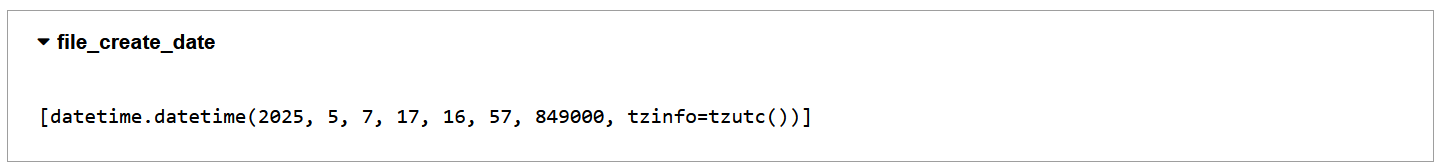

### 2. `processing`
Contains all processed data. The NWB file has a module named `"processed"`. Note that for multiplane these will be present for each plane
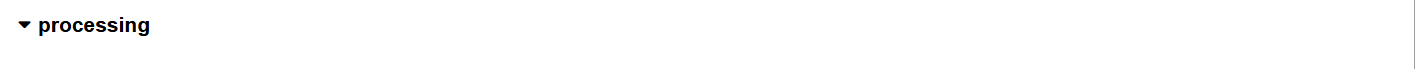

- **`dff`**: ROI response series with dF/F traces.
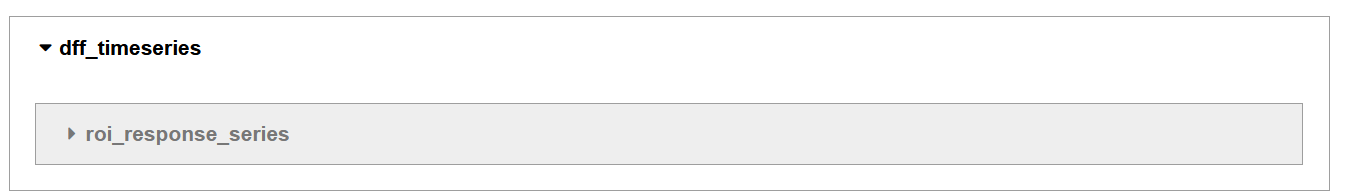
- **`image_segmentation`**: ROI table with the following fields:
  - `dendrite_probability`
  - `id`
  - `image_mask`
  - `is_dendrite`
  - `is_soma`
  - `reference_images`
  - `soma_probability`
 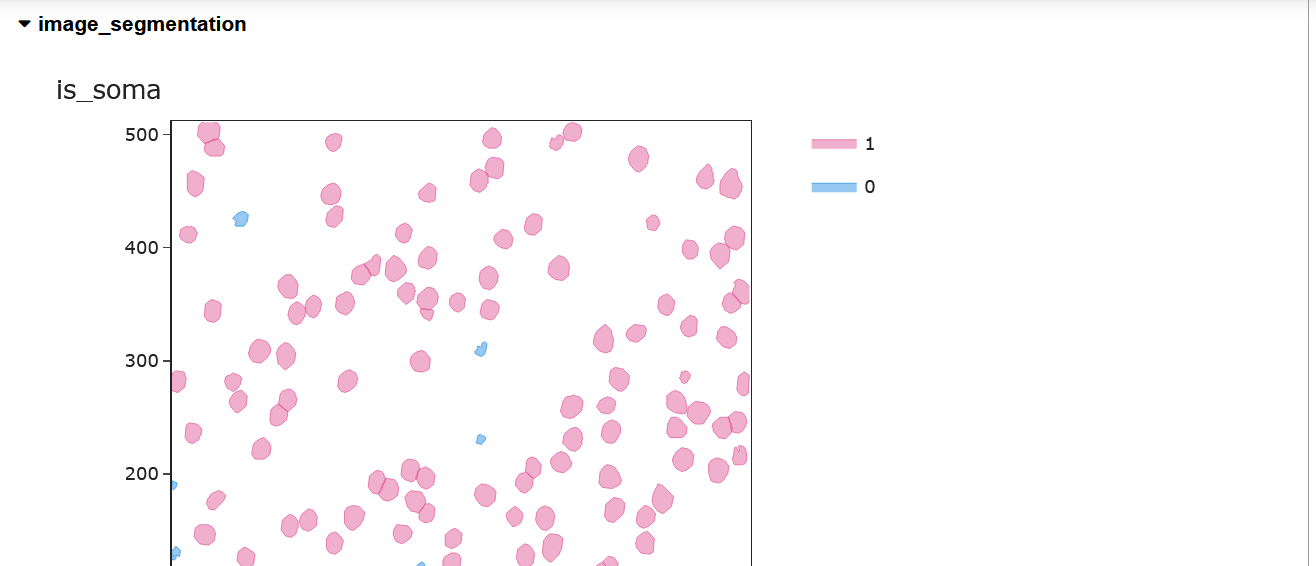
- **`images`**:
  - `Average Projection`
  - `Max Projection`
  - `Segmentation Mask Image`
  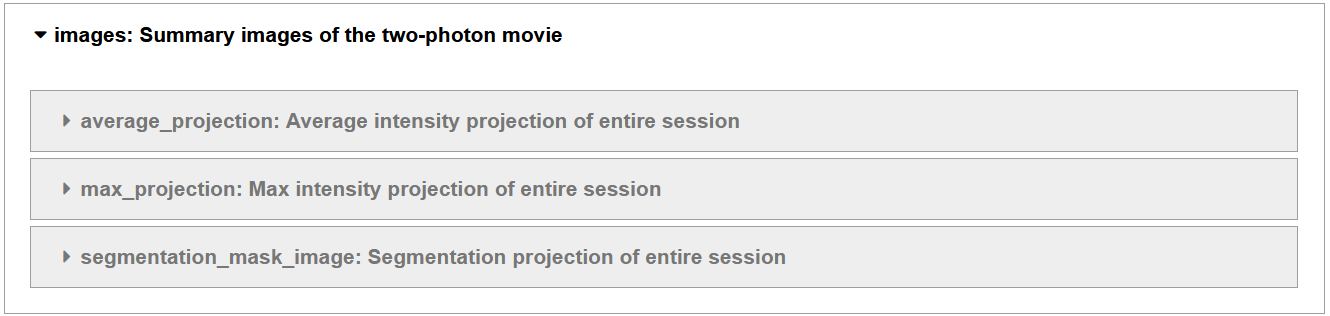
- **`neuropil_corrected`** and **`neuropil_fluorescence`**:
  - `data`
  - `rois`
  - `starting_time`
  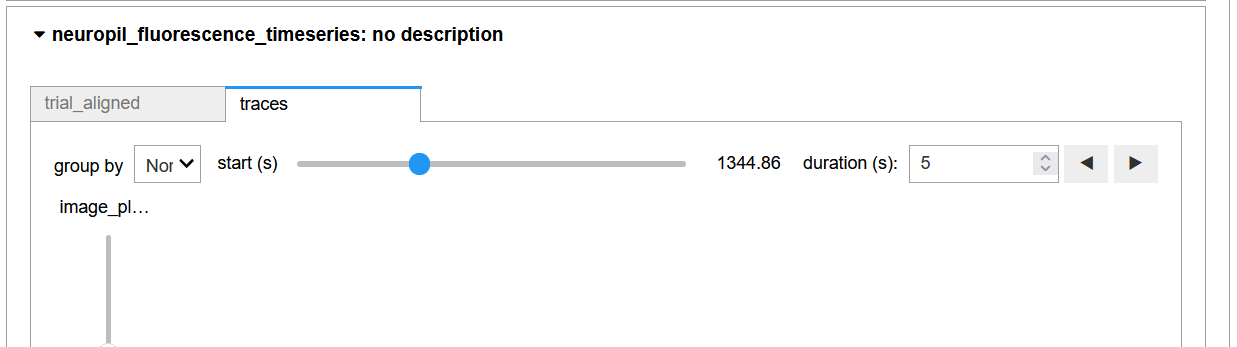
- **`raw`**: Raw neuropil data (may be moved to `acquisition`).

### 3. `devices`
- Metadata for devices used (e.g., Thorlabs microscope).
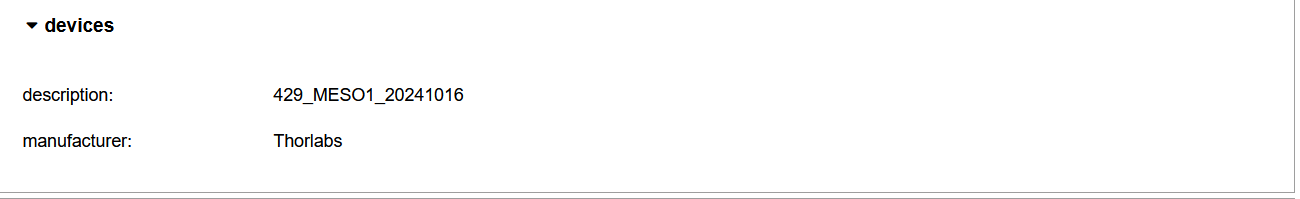

### 4. `imaging_planes`
- Imaging plane details:
  - Optical channel
  - Device
  - Excitation lambda
  - Imaging rate
  - Coordinate system
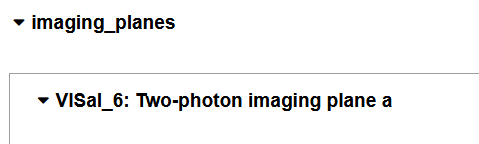

### 5. `intervals`
- TimeIntervals tables for experimental epochs (project-specific).
- Note that these are only added for single-plane sessions

### 6. `subject`
- Subject metadata:
  - `age`
  - `date_of_birth`
  - `sex`
  - `species`
  - `subject_id`
  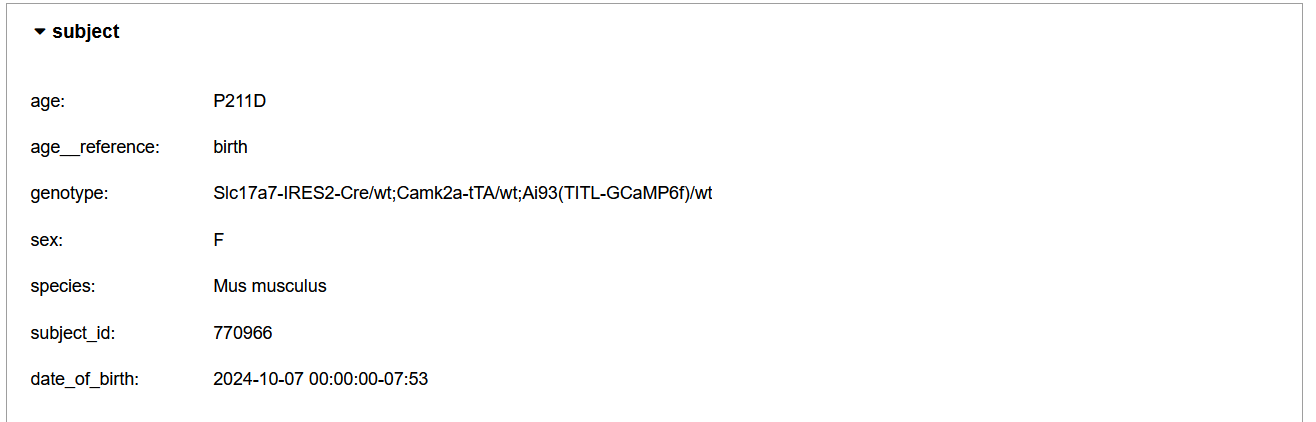
